In [37]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

In [38]:
from sklearn.datasets import fetch_openml

boston = fetch_openml(name="boston", version=1, as_frame=True)  
df = boston.frame  
df.head(5)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


Provjera nedostajućih vrijednosti

In [39]:
df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   CRIM     506 non-null    float64 
 1   ZN       506 non-null    float64 
 2   INDUS    506 non-null    float64 
 3   CHAS     506 non-null    category
 4   NOX      506 non-null    float64 
 5   RM       506 non-null    float64 
 6   AGE      506 non-null    float64 
 7   DIS      506 non-null    float64 
 8   RAD      506 non-null    category
 9   TAX      506 non-null    float64 
 10  PTRATIO  506 non-null    float64 
 11  B        506 non-null    float64 
 12  LSTAT    506 non-null    float64 
 13  MEDV     506 non-null    float64 
dtypes: category(2), float64(12)
memory usage: 48.7 KB


Dataset ima 506 redaka i 14 stupaca  
Svi podaci su popunjeni, nema praznih vrijednosti  
Stupci uključuju različite karakteristike kuća, a MEDV je ciljna varijabla, tj. cijena kuće

In [41]:
X = df.drop("MEDV", axis=1)
y = df["MEDV"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (506, 13)
y shape: (506,)


Definiramo ulazne podatke (X) i ciljne varijable (Y) 
X sadrži sve značajke osim MEDV, a y sadrži samo MEDV, tj. cijenu kuće
X ima 506 redaka i 13 stupaca, a y ima 506 vrijednosti

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.65, random_state=42)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (328, 13)
X_test: (178, 13)
y_train: (328,)
y_test: (178,)


Ovdje se skup podataka dijeli na trening i test skup, 65% podataka ide za učenje, a 35% za testiranje

In [43]:
model = DecisionTreeRegressor(random_state=42)

Kreiram model Decision Tree Regressor,
Random_state=42 koristim da rezultati budu uvijek isti kad ponovno kod se pokrene

In [44]:
model.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

Treniranje model Decision Tree Regressor koristeći trening podatke  
Model uči iz 
    X_train (ulaznih podataka) 
    y_train (ciljne varijable) kako predviđati cijene kuća

In [45]:
y_pred = model.predict(X_test)

print("Stvarne:", y_test.values[:10])
print("Predviđene:", y_pred[:10])

Stvarne: [23.6 32.4 13.6 22.8 16.1 20.  17.8 14.  19.6 16.8]
Predviđene: [22.  32.  18.8 25.  23.2 20.5 22.5 15.  20.2 19.5]


Model predviđa cijenu kuće na test podacima(X_test) 
Prikazuje prvih 10 stvarnih cijana i prvih 10 previđenih cijena 

In [46]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

mae = mean_absolute_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R²:", r2)

RMSE: 4.661508652930756
MAE: 2.9280898876404495
R²: 0.7071701156169596


Gledamo koliko dobro model predviđa cijene kuća 

RMSE - koliko model u prosjeku pogriješi u predviđanju cijena kuća
MAE - koliko model obično promaši cijenu kuće
R² - koliko dobro model uspijeva pogoditi cijene

Veća vrijednost znači da model bolje pogađa

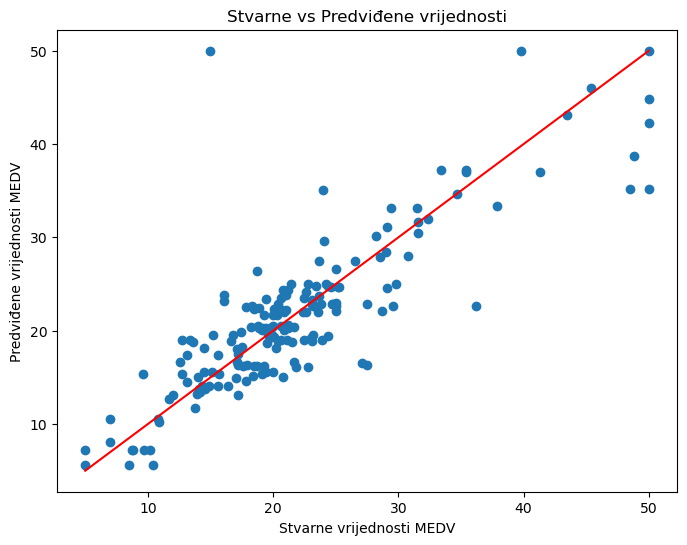

In [47]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Stvarne vrijednosti MEDV")
plt.ylabel("Predviđene vrijednosti MEDV")
plt.title("Stvarne vs Predviđene vrijednosti")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color="red") # dijagonala
plt.show()

Prikazuje se koliko dobro model pogađa cijene kuća
Plave točke su stvarne i predviđene cijene, a crvena linija je ideal - znači kad bi model pogodio točno 

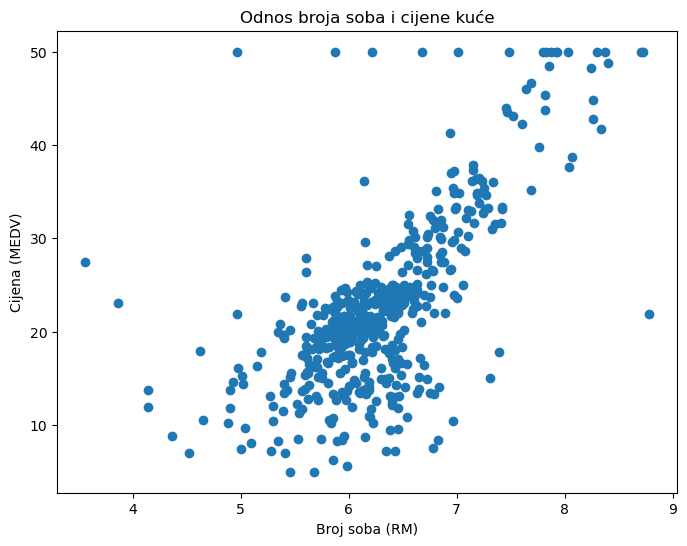

In [48]:
plt.figure(figsize=(8,6))
plt.scatter(df["RM"], df["MEDV"])
plt.xlabel("Broj soba (RM)")
plt.ylabel("Cijena (MEDV)")
plt.title("Odnos broja soba i cijene kuće")
plt.show()

Prikazuje broja soba (RM) i cijene kuće (MEDV)
Svaka točka predstavlja jednu kuću
Većina kuća ima između 5 i 7 soba i cijenu između 10 i 30 tisuća
Kada ovako gledamo možemo reci da više soba znači veću cijenu ali ipak postoje i iznimke

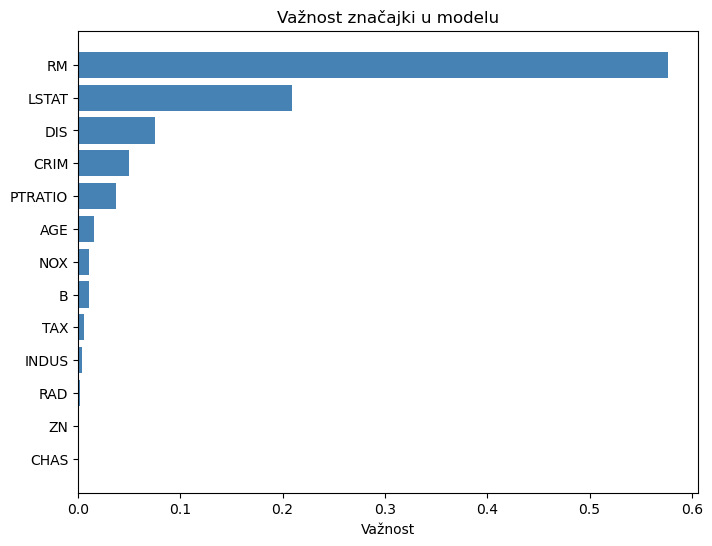

Top 5 najvažnijih značajki:
   znacajka   vaznost
5        RM  0.577165
12    LSTAT  0.209169
7       DIS  0.075135
0      CRIM  0.050045
10  PTRATIO  0.037395


In [51]:
feat_imp = pd.DataFrame({
    'znacajka': X.columns,                   
    'vaznost': model.feature_importances_    
}).sort_values('vaznost', ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(feat_imp['znacajka'], feat_imp['vaznost'], color='steelblue')
plt.xlabel('Važnost')
plt.title('Važnost značajki u modelu')
plt.show()

print("Top 5 najvažnijih značajki:")
print(feat_imp.nlargest(5, 'vaznost'))

Graf važnosti značajki pokazuje koliko svaka varijabla doprinosi predviđanju cijena kuća

Najvažnije značajke su :
                        RM (prosječan broj soba) 
                        LSTAT (% niže društvene klase)
                        
šta znači da model najviše ovisi o tim varijablama
Ostale značajke poput DIS, CRIM i PTRATIO imaju manji utjecaj, ali doprinose konačnom predviđanju

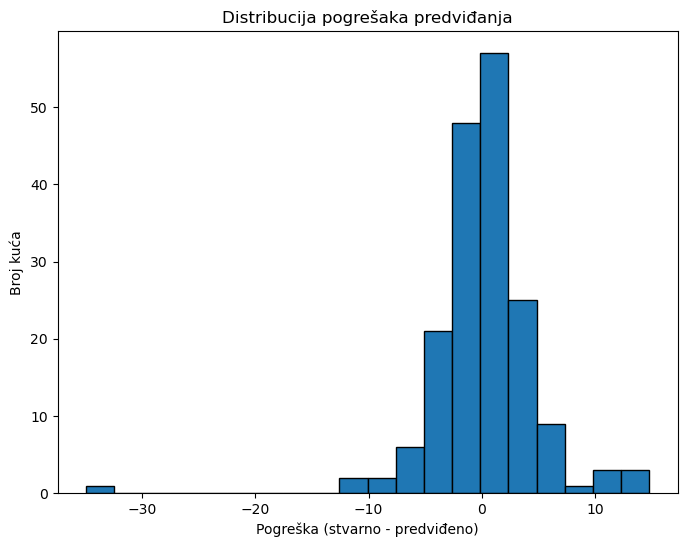

Osnovne statistike pogrešaka (residuals):
Srednja vrijednost: 0.15056179775280898
Standardna devijacija: 4.672219221201176
Minimalna pogreška: -35.0
Maksimalna pogreška: 14.799999999999997


In [59]:
residuals = y_test - y_pred

# Histogram pogrešaka
plt.figure(figsize=(8,6))
plt.hist(residuals, bins=20, edgecolor='black')
plt.xlabel("Pogreška (stvarno - predviđeno)")
plt.ylabel("Broj kuća")
plt.title("Distribucija pogrešaka predviđanja")
plt.show()

# Ispis osnovnih statistika pogrešaka
print("Osnovne statistike pogrešaka (residuals):")
print("Srednja vrijednost:", residuals.mean())
print("Standardna devijacija:", residuals.std())
print("Minimalna pogreška:", residuals.min())
print("Maksimalna pogreška:", residuals.max())

Pokazuje razlike između stvarnih i predviđenih cijena kuća
Prosječna pogreška je oko 0,15 šta znači da model većinom ne precjenjuje niti podcjenjuje cijene
Većina pogrešaka je mala (standardna devijacija 4,67), ali postoje i rijetke kuće gdje model pogriješi više 
Model dobro radi za većinu kuća